In [245]:
import numpy as np

def linear_congruential(x0, a, c, m, k):
    """
    Generate a sequence of pseudo-random numbers using the linear congruential generator algorithm.
    Parameters:
    x0: The seed value (initial value).
    a: The multiplier.
    c: The increment.
    m: The modulus.
    k: The number of pseudo-random numbers to generate.

    Returns:
    A list of pseudo-random numbers generated by the linear congruential generator.
    """
    x = [x0]
    for _ in range(k):
        x0 = (a*x0+c) % m

        x.append(x0)
    
    U = np.array(x) / m
    return U

x0 = 42
a = 16807
c = 0
m = 2**31 - 1
k = 10000

random_numbers = linear_congruential(x0, a, c, m, k)

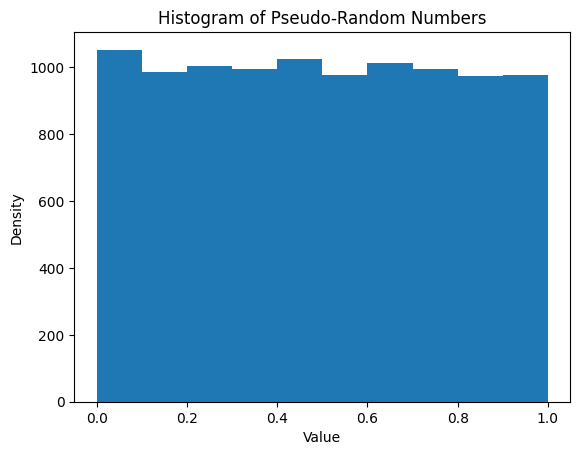

In [246]:
import matplotlib.pyplot as plt

plt.hist(random_numbers, bins=10)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of Pseudo-Random Numbers')
plt.show()

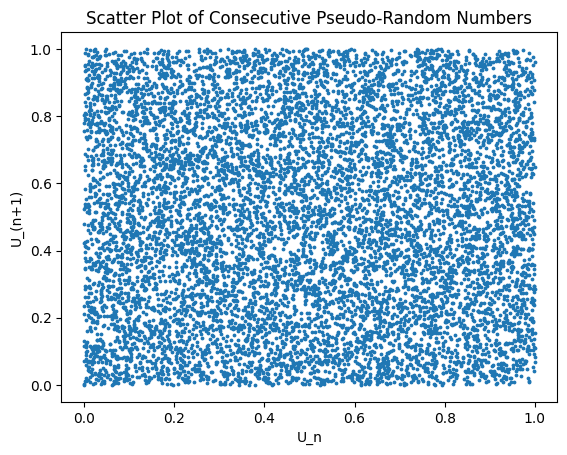

In [247]:
plt.scatter(random_numbers[:-1], random_numbers[1:], s=3)
plt.xlabel('U_n')
plt.ylabel('U_(n+1)')
plt.title('Scatter Plot of Consecutive Pseudo-Random Numbers')
plt.show()

In [248]:
#Statical test, chi-squared test
classes = 10
expected = len(random_numbers) / classes
observed, _ = np.histogram(random_numbers, bins=classes)
T = np.sum((observed - expected)**2 / expected)

T, expected, observed

(np.float64(5.488351164883511),
 1000.1,
 array([1053,  987, 1004,  996, 1025,  978, 1012,  995,  975,  976]))

In [249]:
m = 0
df = classes-1-m
print(f"Degrees of freedom: {df}")

#Critical value from table with df = 9, critical value = 16,919, T has been calculated to T = 5.488
#As T < critical value, we can not reject the null hypothesis that the numbers are uniformly distributed.

Degrees of freedom: 9


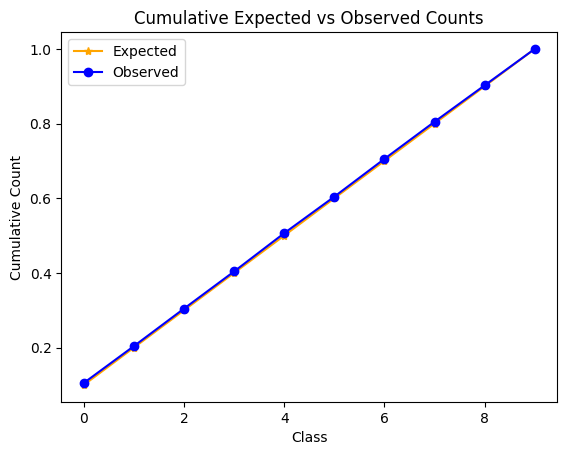

In [250]:
expected_list = [i*expected for i in range(1, classes+1)]
observed_list = [np.sum(observed[:i]) for i in range(1, classes+1)]

observed_array = np.array(observed_list)/len(random_numbers)
expected_array = np.array(expected_list)/len(random_numbers)


plt.plot(expected_array, label='Expected', color='orange', marker='*')
plt.plot(observed_array, label='Observed', color='blue', marker='o')
plt.xlabel('Class')
plt.ylabel('Cumulative Count')
plt.title('Cumulative Expected vs Observed Counts')
plt.legend()
plt.show()

In [251]:
Dn = np.max(np.abs(observed_array - expected_array))

n = len(random_numbers)
adjusted_test = (np.sqrt(n)+0.12+0.11/np.sqrt(n))*Dn

#adjusted_test = 0.65 < 1.358
#we can not reject the null hypothesis that the numbers are uniformly distributed.

In [252]:
# Above / below test, run-test1
median_ = np.median(random_numbers)
n1 = np.sum(random_numbers > median_)
n2 = np.sum(random_numbers < median_)

def count_runs(median_, number):
    r = 1
    for i in range(1, len(number)):
        if number[i] > median_ and number[i-1] <= median_:
            r += 1
        elif number[i] <= median_ and number[i-1] > median_:
            r += 1
    return r

T = count_runs(median_, random_numbers)


mean_ = 2*(n1*n2)/(n1+n2)+1
var_ = 2*(n1*n2*(2*n1*n2-n1-n2)/((n1+n2)**2*(n1+n2-1)))
std_ = np.sqrt(var_)

Z = (T - mean_)/std_

#Test above or under critical value of 1.96
Z, T, mean_, std_

(np.float64(0.24001200210037504),
 5013,
 np.float64(5001.0),
 np.float64(49.997499687459374))

In [253]:
# Up down test
from collections import Counter

def count_runs_idx(number):
    r = 1
    idx = [0]
    for i in range(1, len(number)):
        if number[i] < number[i-1]:
            r += 1
            idx.append(i)
    return r, idx

r, idx = count_runs_idx(random_numbers)

idx = np.array(idx)

run_lengths = np.diff(idx)
last_length = len(random_numbers)-1 - idx[-1]
run_lengths = np.append(run_lengths, last_length)


In [254]:
import numpy as np

A = np.array([
    [4529.4,  9044.9,  13568.0,  18091.0,  22615.0,  27892.0],
    [9044.9, 18097.0,  27139.0,  36187.0,  45234.0,  55789.0],
    [13568.0, 27139.0,  40721.0,  54281.0,  67852.0,  83685.0],
    [18091.0, 36187.0,  54281.0,  72414.0,  90470.0, 111580.0],
    [22615.0, 45234.0,  67852.0,  90470.0, 113262.0, 139476.0],
    [27892.0, 55789.0,  83685.0, 111580.0, 139476.0, 172860.0]
])

B = np.array([
    1/6,
    5/24,
    11/120,
    19/720,
    29/5040,
    1/840
])

n = len(random_numbers)

R1 = np.unique(run_lengths, return_counts=True)[1]

R = np.array([R1[0:5]]).T
R =np.append(R, np.sum(R1[5:]))

Z = (1 / (n - 6)) * (R - n * B).T @ A @ (R - n * B)

#Test for critical value 12.592, 6 degrees of freedom, alpha = 0.05
Z


np.float64(1.4643584768890536)

In [255]:
# Correlation test

h = 4
n = len(random_numbers)

cor_test = 1/(n-h) * np.sum((random_numbers[h:]*random_numbers[:-h]))

In [256]:
print(f"Correlation for h={h}: {cor_test:.4f}")

expected_mean = 0.25
variance = 7 / (144 * k)     
std_dev = np.sqrt(variance)

Z = (cor_test - expected_mean) / std_dev
print(f"Standardized correlation test statistic: {Z:.2f}")

critical_value = 1.96

if abs(Z) < critical_value:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation (the random number generator has a defect).")


Correlation for h=4: 0.2466
Standardized correlation test statistic: -1.52
Fail to reject H0: No significant evidence of correlation (behaves like true white noise).


# New test

In [461]:
import numpy as np

def linear_congruential(x0, a, c, m, k):
    """
    Generate a sequence of pseudo-random numbers using the linear congruential generator algorithm.
    Parameters:
    x0: The seed value (initial value).
    a: The multiplier.
    c: The increment.
    m: The modulus.
    k: The number of pseudo-random numbers to generate.

    Returns:
    A list of pseudo-random numbers generated by the linear congruential generator.
    """
    x = [x0]
    for _ in range(k):
        x0 = (a*x0+c) % m

        x.append(x0)
    
    U = np.array(x) / m
    return U

x0 = 42
a = 100
c = 5
m = 2**16-1
k = 10000

random_numbers = linear_congruential(x0, a, c, m, k)

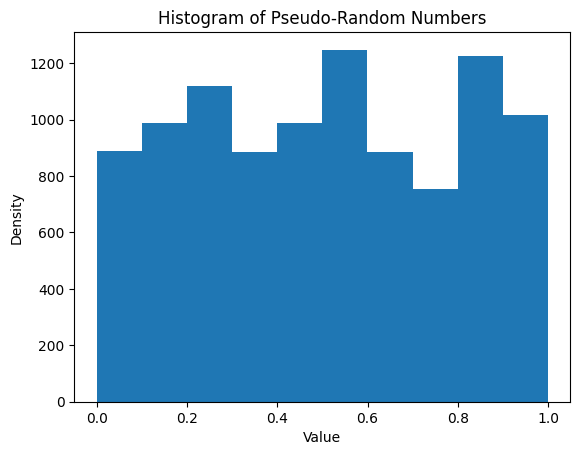

In [462]:
import matplotlib.pyplot as plt

plt.hist(random_numbers, bins=10)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of Pseudo-Random Numbers')
plt.show()

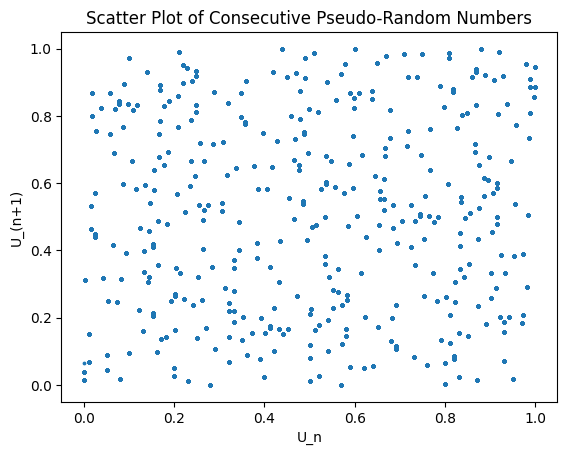

In [463]:
plt.scatter(random_numbers[:-1], random_numbers[1:], s=3)
plt.xlabel('U_n')
plt.ylabel('U_(n+1)')
plt.title('Scatter Plot of Consecutive Pseudo-Random Numbers')
plt.show()

In [464]:
#Statical test, chi-squared test
classes = 10
expected = len(random_numbers) / classes
observed, _ = np.histogram(random_numbers, bins=classes)
T = np.sum((observed - expected)**2 / expected)

T, expected, observed

(np.float64(224.66643335666433),
 1000.1,
 array([ 890,  988, 1120,  885,  989, 1248,  887,  755, 1224, 1015]))

In [465]:
m = 0
df = classes-1-m
print(f"Degrees of freedom: {df}")

#Critical value from table with df = 9, critical value = 16,919, T has been calculated to T = 5.488
#As T < critical value, we can not reject the null hypothesis that the numbers are uniformly distributed.

Degrees of freedom: 9


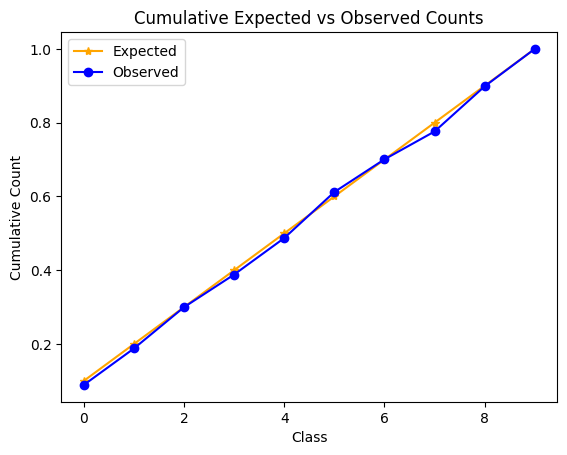

In [466]:
expected_list = [i*expected for i in range(1, classes+1)]
observed_list = [np.sum(observed[:i]) for i in range(1, classes+1)]

observed_array = np.array(observed_list)/len(random_numbers)
expected_array = np.array(expected_list)/len(random_numbers)


plt.plot(expected_array, label='Expected', color='orange', marker='*')
plt.plot(observed_array, label='Observed', color='blue', marker='o')
plt.xlabel('Class')
plt.ylabel('Cumulative Count')
plt.title('Cumulative Expected vs Observed Counts')
plt.legend()
plt.show()

In [467]:
Dn = np.max(np.abs(observed_array - expected_array))

n = len(random_numbers)
adjusted_test = (np.sqrt(n)+0.12+0.11/np.sqrt(n))*Dn
print(f"Adjusted test statistic: {adjusted_test:.4f}")

#adjusted_test = 0.65 < 1.338
#we can not reject the null hypothesis that the numbers are uniformly distributed.

Adjusted test statistic: 2.3908


In [468]:
# Above / below test, Wald-Wolfowitz
median_ = np.median(random_numbers)
n1 = np.sum(random_numbers > median_)
n2 = np.sum(random_numbers < median_)

def count_runs(median_, number):
    r = 1
    for i in range(1, len(number)):
        if number[i] > median_ and number[i-1] <= median_:
            r += 1
        elif number[i] <= median_ and number[i-1] > median_:
            r += 1
    return r

T = count_runs(median_, random_numbers)


mean_ = 2*(n1*n2)/(n1+n2)+1
var_ = 2*(n1*n2*(2*n1*n2-n1-n2)/((n1+n2)**2*(n1+n2-1)))
std_ = np.sqrt(var_)

Z = (T - mean_)/std_

Z, T, n1, n2

(np.float64(0.23083182941363808), 5000, np.int64(4999), np.int64(4976))

In [471]:
# Up down test
from collections import Counter

def count_runs_idx(number):
    r = 1
    idx = [0]
    for i in range(1, len(number)):
        if number[i] < number[i-1]:
            r += 1
            idx.append(i)
    if len(number)-1 > idx[-1]:
        r += 1
        idx.append(len(number)-1)
    return r, idx

r, idx = count_runs_idx(random_numbers)

idx = np.array(idx)

run_lengths = np.diff(idx)


In [472]:
import numpy as np

A = np.array([
    [4529.4,  9044.9,  13568.0,  18091.0,  22615.0,  27892.0],
    [9044.9, 18097.0,  27139.0,  36187.0,  45234.0,  55789.0],
    [13568.0, 27139.0,  40721.0,  54281.0,  67852.0,  83685.0],
    [18091.0, 36187.0,  54281.0,  72414.0,  90470.0, 111580.0],
    [22615.0, 45234.0,  67852.0,  90470.0, 113262.0, 139476.0],
    [27892.0, 55789.0,  83685.0, 111580.0, 139476.0, 172860.0]
])

B = np.array([
    1/6,
    5/24,
    11/120,
    19/720,
    29/5040,
    1/840
])

n = len(random_numbers)

R = np.zeros(6).astype(int)

R[0] = int(np.sum(run_lengths==1))
R[1] = int(np.sum(run_lengths==2))
R[2] = int(np.sum(run_lengths==3))
R[3] = int(np.sum(run_lengths==4))
R[4] = int(np.sum(run_lengths==5))
R[5] = int(np.sum(run_lengths>5))


R1 = np.unique(run_lengths, return_counts=True)[1]

R = np.array([R1[0:5]]).T
R =np.append(R, np.sum(R1[5:]))

Z = (1 / (n - 6)) * (R - n * B).T @ A @ (R - n * B)
Z, R


(np.float64(54.460851922018286), array([1823, 2159,  808,  260,   79,    0]))

In [426]:
# Correlation test

h = 4
n = len(random_numbers)

cor_test = 1/(n-h) * np.sum((random_numbers[h:]*random_numbers[:-h]))

In [427]:
print(f"Correlation for h={h}: {cor_test:.4f}")

expected_mean = 0.25
variance = 7 / (144 * k)     
std_dev = np.sqrt(variance)

Z = (cor_test - expected_mean) / std_dev
print(f"Standardized correlation test statistic: {Z:.2f}")

critical_value = 1.96

if abs(Z) < critical_value:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation (the random number generator has a defect).")


Correlation for h=4: 0.2566
Standardized correlation test statistic: 2.98
Reject H0: Significant evidence of correlation (the random number generator has a defect).


# System generator

In [473]:
import numpy as np

def linear_congruential(x0, a, c, m, k):
    """
    Generate a sequence of pseudo-random numbers using the linear congruential generator algorithm.
    Parameters:
    x0: The seed value (initial value).
    a: The multiplier.
    c: The increment.
    m: The modulus.
    k: The number of pseudo-random numbers to generate.

    Returns:
    A list of pseudo-random numbers generated by the linear congruential generator.
    """
    x = [x0]
    for _ in range(k):
        x0 = (a*x0+c) % m

        x.append(x0)
    
    U = np.array(x) / m
    return U

x0 = 42
a = 16807
c = 0
m = 2**31 - 1
k = 10000

random_numbers = linear_congruential(x0, a, c, m, k)

np.random.seed(42)
random_numbers = np.random.uniform(0,1, size=k)

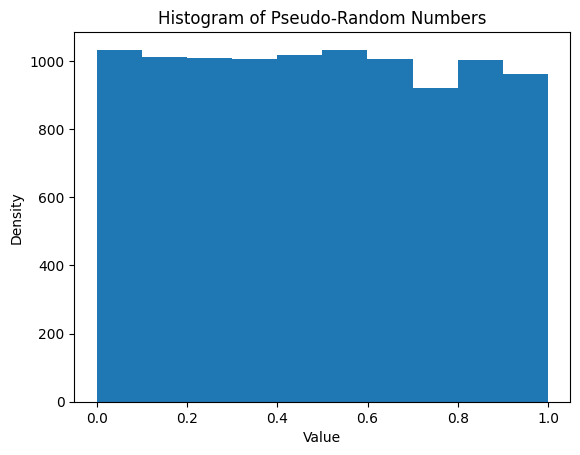

In [474]:
import matplotlib.pyplot as plt

plt.hist(random_numbers, bins=10)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of Pseudo-Random Numbers')
plt.show()

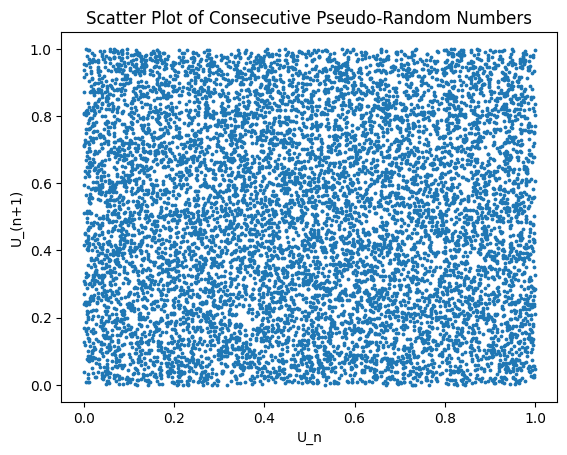

In [475]:
plt.scatter(random_numbers[:-1], random_numbers[1:], s=3)
plt.xlabel('U_n')
plt.ylabel('U_(n+1)')
plt.title('Scatter Plot of Consecutive Pseudo-Random Numbers')
plt.show()

In [476]:
#Statical test, chi-squared test
classes = 10
expected = len(random_numbers) / classes
observed, _ = np.histogram(random_numbers, bins=classes)
T = np.sum((observed - expected)**2 / expected)

T

np.float64(10.1)

In [477]:
m = 0
df = classes-1-m
print(f"Degrees of freedom: {df}")

#Critical value from table with df = 9, critical value = 16,919, T has been calculated to T = 10.1
#As T < critical value, we can not reject the null hypothesis that the numbers are uniformly distributed.

Degrees of freedom: 9


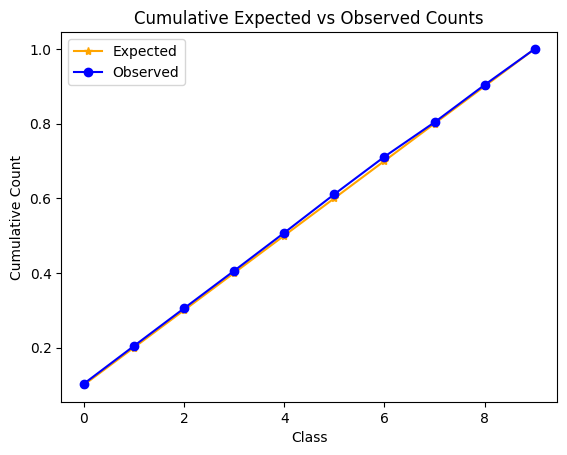

In [478]:
expected_list = [i*expected for i in range(1, classes+1)]
observed_list = [np.sum(observed[:i]) for i in range(1, classes+1)]

observed_array = np.array(observed_list)/len(random_numbers)
expected_array = np.array(expected_list)/len(random_numbers)


plt.plot(expected_array, label='Expected', color='orange', marker='*')
plt.plot(observed_array, label='Observed', color='blue', marker='o')
plt.xlabel('Class')
plt.ylabel('Cumulative Count')
plt.title('Cumulative Expected vs Observed Counts')
plt.legend()
plt.show()

In [479]:
Dn = np.max(np.abs(observed_array - expected_array))

n = len(random_numbers)
adjusted_test = (np.sqrt(n)+0.12+0.11/np.sqrt(n))*Dn
print(f"Adjusted test statistic: {adjusted_test:.4f}")

#adjusted_test = 0.65 < 1.338
#we can not reject the null hypothesis that the numbers are uniformly distributed.

Adjusted test statistic: 1.1314


In [480]:
# Above / below test
median_ = np.median(random_numbers)
n1 = np.sum(random_numbers > median_)
n2 = np.sum(random_numbers < median_)

def count_runs(median_, number):
    r = 1
    for i in range(1, len(number)):
        if number[i] > median_ and number[i-1] <= median_:
            r += 1
        elif number[i] <= median_ and number[i-1] > median_:
            r += 1
    return r

T = count_runs(median_, random_numbers)


mean_ = 2*(n1*n2)/(n1+n2)+1
var_ = 2*(n1*n2*(2*n1*n2-n1-n2)/((n1+n2)**2*(n1+n2-1)))
std_ = np.sqrt(var_)

Z = (T - mean_)/std_

Z

np.float64(1.2400620108519378)

In [481]:
# Up down test
from collections import Counter

def count_runs_idx(number):
    r = 1
    idx = [0]
    for i in range(1, len(number)):
        if number[i] < number[i-1]:
            r += 1
            idx.append(i)
    if len(number)-1 > idx[-1]:
        r += 1
        idx.append(len(number)-1)
    return r, idx

r, idx = count_runs_idx(random_numbers)

idx = np.array(idx)

run_lengths = np.diff(idx)


In [482]:
import numpy as np

A = np.array([
    [4529.4,  9044.9,  13568.0,  18091.0,  22615.0,  27892.0],
    [9044.9, 18097.0,  27139.0,  36187.0,  45234.0,  55789.0],
    [13568.0, 27139.0,  40721.0,  54281.0,  67852.0,  83685.0],
    [18091.0, 36187.0,  54281.0,  72414.0,  90470.0, 111580.0],
    [22615.0, 45234.0,  67852.0,  90470.0, 113262.0, 139476.0],
    [27892.0, 55789.0,  83685.0, 111580.0, 139476.0, 172860.0]
])

B = np.array([
    1/6,
    5/24,
    11/120,
    19/720,
    29/5040,
    1/840
])

n = len(random_numbers)

R1 = np.unique(run_lengths, return_counts=True)[1]

R = np.array([R1[0:5]]).T
R =np.append(R, np.sum(R1[5:]))

Z = (1 / (n - 6)) * (R - n * B).T @ A @ (R - n * B)
Z, R


(np.float64(1.2774246003886593), array([1661, 2096,  900,  267,   60,   13]))

In [483]:
# Correlation test

h = 4
n = len(random_numbers)

cor_test = 1/(n-h) * np.sum((random_numbers[h:]*random_numbers[:-h]))

In [484]:
print(f"Correlation for h={h}: {cor_test:.4f}")

expected_mean = 0.25
variance = 7 / (144 * k)     
std_dev = np.sqrt(variance)

Z = (cor_test - expected_mean) / std_dev
print(f"Standardized correlation test statistic: {Z:.2f}")

critical_value = 1.96

if abs(Z) < critical_value:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation (the random number generator has a defect).")


Correlation for h=4: 0.2439
Standardized correlation test statistic: -2.75
Reject H0: Significant evidence of correlation (the random number generator has a defect).


# Part 3

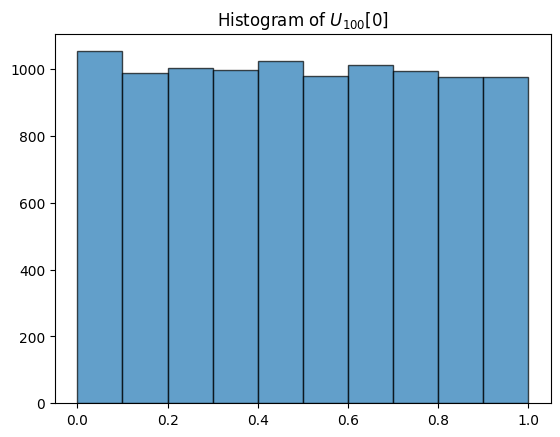

In [485]:
x0 = 42 # seed
M = 2**31-1
a = 16807
c = 0
num_iters = 10000
U_100 = []
for i in range(100):
    U = linear_congruential(x0, a, c, M, num_iters)
    U_100.append(U)
    x0 = int(U[-1] * M) 

plt.hist(U_100[0], bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of $U_{100}[0]$')
plt.show()

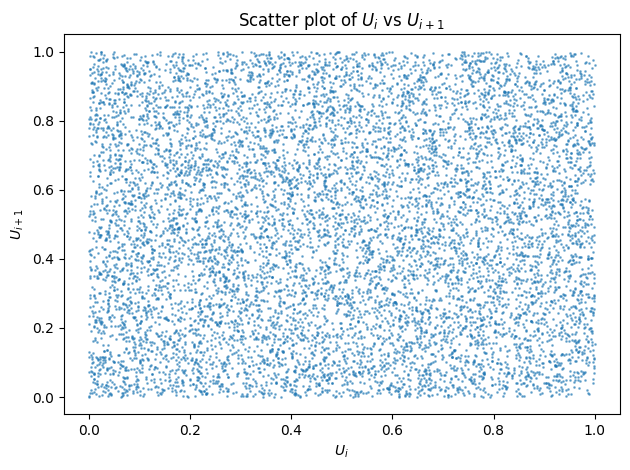

In [486]:
# Scatter plot: U_i vs U_{i+1}
plt.scatter(U_100[0][:-1], U_100[0][1:], s=1, alpha=0.5)
plt.title('Scatter plot of $U_i$ vs $U_{i+1}$')
plt.xlabel('$U_i$')
plt.ylabel('$U_{i+1}$')
plt.tight_layout()
plt.show()

In [487]:
# chi-square test
classes = 10
critical_value = 16.919

reject_count = 0
for U in U_100:
    observed, _ = np.histogram(U, classes)
    expected_class = len(U) / classes
    T = np.sum((observed - expected_class)**2 / expected_class)
    
    if T >= critical_value:
        reject_count += 1

print(f"Chi-Square Test: H0 rejected {reject_count} times out of 100.")

Chi-Square Test: H0 rejected 2 times out of 100.


In [488]:
# Kolmogorov-Smirnov test
classes = 10
reject_count = 0

for U in U_100:
    observed, _ = np.histogram(U, classes)
    expected_class = len(U) / classes
    
    observed_cdf = np.cumsum(observed) / len(U)
    theoretical_cdf = np.cumsum([expected_class] * classes) / len(U)
    
    D = np.max(np.abs(observed_cdf - theoretical_cdf))
    adjusted_D = (np.sqrt(len(U)) + 0.12 + 0.11 / np.sqrt(len(U))) * D
    
    if adjusted_D >= 1.358: 
        reject_count += 1

print(f"KS Test: H0 rejected {reject_count} times out of 100.")

KS Test: H0 rejected 5 times out of 100.


In [489]:
# run test I
reject_count = 0

for U in U_100:
    median_U = np.median(U)
    runs_arr = np.array([1 if x > median_U else -1 for x in U if x != median_U])
    
    n1 = np.sum(runs_arr == 1)
    n2 = np.sum(runs_arr == -1)
    
    num_runs = 1
    for i in range(1, len(runs_arr)):
        if runs_arr[i] != runs_arr[i-1]:
            num_runs += 1
            
    n = n1 + n2
    expected_runs = (2 * n1 * n2) / n + 1
    var_runs = (2 * n1 * n2 * (2 * n1 * n2 - n)) / ((n ** 2) * (n - 1))
    
    Z_runs = (num_runs - expected_runs) / np.sqrt(var_runs)
    
    if np.abs(Z_runs) >= 1.96:
        reject_count += 1

print(f"Run-Test I: H0 rejected {reject_count} times out of 100.")

Run-Test I: H0 rejected 5 times out of 100.


In [490]:
# run-test II
from collections import Counter
reject_count = 0

A = np.array([
    [4529.4, 9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
])
B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

for U in U_100:
    run_lengths = []
    run_length = 1
    for i in range(1, len(U)):
        if U[i] < U[i-1]:
            run_lengths.append(run_length)
            run_length = 1
        else:
            run_length += 1
    run_lengths.append(run_length)

    run_lengths_bunched = [6 if length >= 6 else length for length in run_lengths]
    run_length_counts = Counter(run_lengths_bunched)
    R = np.array([run_length_counts.get(i, 0) for i in range(1, 7)])

    Z = 1 / len(U) * (R - len(U) * B).T @ A @ (R - len(U) * B)
    if Z >= 12.592:
        reject_count += 1

print(f"Run-Test II: H0 rejected {reject_count} times out of 100.")

Run-Test II: H0 rejected 9 times out of 100.


In [491]:
# correlation test
h = 4
expected_mean = 0.25
critical_value = 1.96  

reject_count = 0
for U in U_100:
    variance = 7 / (144 * len(U))
    std_dev = np.sqrt(variance)
    
    c = (1 / (len(U) - h)) * sum(U[i] * U[i + h] for i in range(len(U) - h))
    Z = (c - expected_mean) / std_dev
    
    if abs(Z) >= critical_value:
        reject_count += 1
        
print(f"Correlation Test (h={h}): H0 rejected {reject_count} times out of 100.")

Correlation Test (h=4): H0 rejected 12 times out of 100.
